**Warehouses**

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path

In [16]:
file_path = Path.cwd().parent.parent/"Excel"/"3_Warehouses.xlsx"
df = pd.read_excel(file_path)
df

,Warehouse_ID,Warehouse_Name,Region,Capacity,Operating_Cost
0,W100,Warehouse 1,South,-500,131401.36
1,W101,Warehouse 2,West,-500,409621.09
2,W102,Warehouse 3,South,-500,200386.72
3,W103,Warehouse 4,West,-500,378891.66
4,W104,Warehouse 5,West,-500,239004.95
5,W105,Warehouse 6,West,79322,310261.89
6,W106,Warehouse 7,East,-500,424675.30
7,W107,Warehouse 8,South,-500,411874.50
8,W108,Warehouse 9,North,-500,439890.43
9,W109,Warehouse 10,North,-500,76827.80


In [17]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Warehouse_ID    21 non-null     object 
 1   Warehouse_Name  21 non-null     object 
 2   Region          21 non-null     object 
 3   Capacity        21 non-null     int64  
 4   Operating_Cost  21 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 972.0+ bytes


In [18]:
# Capitalize, Trimming and Consistent null values
columns = ["Warehouse_ID", "Warehouse_Name", "Region"]
for col in columns:
    df[col] = df[col].str.capitalize()
    df[col] = df[col].str.strip()
nulls = ["N/a", "Na", "Null", "Unknown", ""]
df.replace(nulls, np.nan, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Warehouse_ID    21 non-null     object 
 1   Warehouse_Name  21 non-null     object 
 2   Region          21 non-null     object 
 3   Capacity        21 non-null     int64  
 4   Operating_Cost  21 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 972.0+ bytes


In [19]:
# Dropping duplicates except nulls
mask = df["Warehouse_ID"].notna()
df = pd.concat([
    df[mask].drop_duplicates(subset=["Warehouse_ID"], keep="first"),
    df[~mask]
]).sort_index()
df.reset_index(drop=True, inplace=True)
df.head()

,Warehouse_ID,Warehouse_Name,Region,Capacity,Operating_Cost
0,W100,Warehouse 1,South,-500,131401.36
1,W101,Warehouse 2,West,-500,409621.09
2,W102,Warehouse 3,South,-500,200386.72
3,W103,Warehouse 4,West,-500,378891.66
4,W104,Warehouse 5,West,-500,239004.95


In [20]:
# Replacing null values in Warehouse ID
for i in range(len(df)):
    value = df.loc[i, "Warehouse_ID"]
    if not pd.notna(value):
        df.loc[i, "Warehouse_ID"] = f"W{1000+i}"
df["Warehouse_ID"].isna().sum()
df["Warehouse_ID"].duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Warehouse_ID    20 non-null     object 
 1   Warehouse_Name  20 non-null     object 
 2   Region          20 non-null     object 
 3   Capacity        20 non-null     int64  
 4   Operating_Cost  20 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 932.0+ bytes


In [21]:
# Replacing null values in Warehouse Name
for i in range(len(df)):
    value = df.loc[i, "Warehouse_Name"]
    if not pd.notna(value):
        df.loc[i, "Warehouse_Name"] = f"Warehouse {i+1}"
df["Warehouse_ID"].isna().sum()
df["Warehouse_ID"].duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Warehouse_ID    20 non-null     object 
 1   Warehouse_Name  20 non-null     object 
 2   Region          20 non-null     object 
 3   Capacity        20 non-null     int64  
 4   Operating_Cost  20 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 932.0+ bytes


In [22]:
df["Region"].unique()

array(['South', 'West', 'East', 'North'], dtype=object)

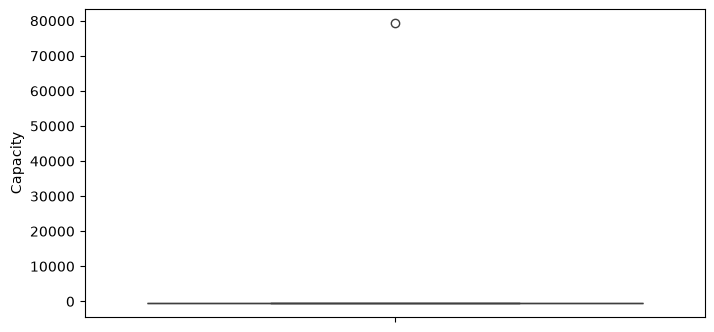

count       20.00000
mean      3491.10000
std      17848.74181
min       -500.00000
25%       -500.00000
50%       -500.00000
75%       -500.00000
max      79322.00000
Name: Capacity, dtype: float64

In [23]:
# Checking negatives or outliers
plt.figure(figsize=(8,4))
sb.boxplot(df["Capacity"])
plt.show()
df["Capacity"].describe()

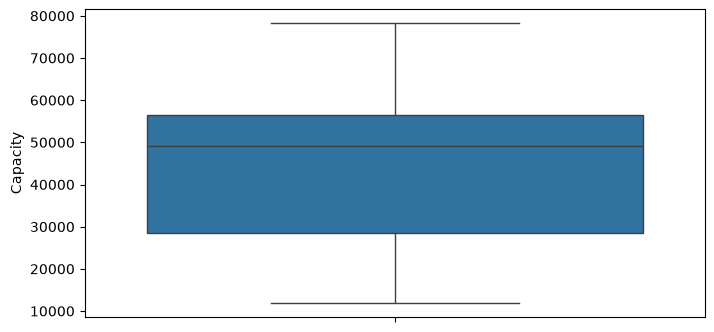

In [24]:
# Adding random values for capacity as there is no source for its true value
np.random.seed(0)
df['Capacity'] = np.random.randint(10000, 80001, size=len(df))
plt.figure(figsize=(8,4))
sb.boxplot(df["Capacity"])
plt.show()

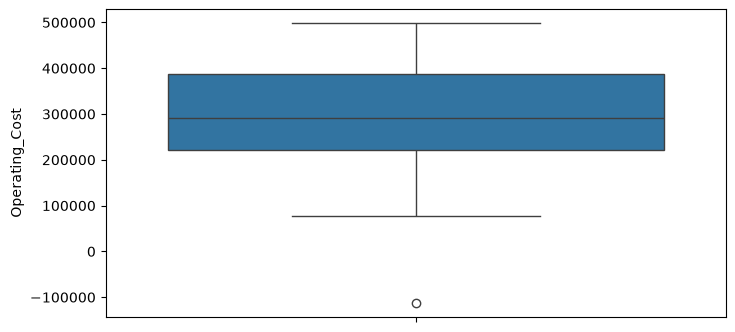

In [25]:
# Checking negatives or outliers
plt.figure(figsize=(8,4))
sb.boxplot(df["Operating_Cost"])
plt.show()

In [26]:
df.loc[df["Operating_Cost"]<0, "Operating_Cost"] *= -1
df["Operating_Cost"].describe()

count        20.000000
mean     286886.711000
std      122545.579617
min       76827.800000
25%      221247.002500
50%      290345.020000
75%      386574.017500
max      498436.840000
Name: Operating_Cost, dtype: float64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Warehouse_ID    20 non-null     object 
 1   Warehouse_Name  20 non-null     object 
 2   Region          20 non-null     object 
 3   Capacity        20 non-null     int32  
 4   Operating_Cost  20 non-null     float64
dtypes: float64(1), int32(1), object(3)
memory usage: 852.0+ bytes


In [28]:
df.to_csv("../../Data/Cleaned/Warehouses.csv", index=False)